# Lesson 5: Quadratic Proces and Bids

Name

In [ ]:
lesson_number = 1
print(f'lesson{lesson_number}')

In [ ]:
#@title Connect to Google Drive {display-mode:"form"}
CONNECT_TO_DRIVE = False #@param {type:"boolean"}

import os

if CONNECT_TO_DRIVE:
    from google.colab import drive
    # Mount Google Drive
    drive.mount('/content/drive')

    # Define the desired working directory path
    working_dir = f'/content/drive/MyDrive/ich-modelling-2026'
    lesson_folder = f'lesson-{lesson_number}'
    lesson_dir = os.path.join(working_dir, lesson_folder)

    # Create the working directory if it doesn't exist
    if not os.path.exists(working_dir):
        os.makedirs(working_dir)
        print(f"Directory '{working_dir}' created.")
    else:
        print(f"Directory '{working_dir}' already exists.")

    # Create the lesson directory if it doesn't exist
    if not os.path.exists(lesson_dir):
        os.makedirs(lesson_dir)
        print(f"Directory '{lesson_dir}' created.")
    else:
        print(f"Directory '{lesson_dir}' already exists.")

    # Change the current working directory to the lesson directory
    os.chdir(lesson_dir)

    print(f"Current working directory: {os.getcwd()}")
else:
    print("Not connecting to Google Drive.")

In [ ]:
#@title Install Packages {display-mode:"form"}
INSTALL_PACKAGES = False #@param {type:"boolean"}

import os

# Check if packages have already been installed in this session to prevent re-installation
if INSTALL_PACKAGES and not os.environ.get('PYPSA_PACKAGES_INSTALLED'):
  !pip install git+https://github.com/pypsa/pypsa
  !pip install pypsa[excel] 
  !pip install folium mapclassify cartopy gurobipy
  os.environ['PYPSA_PACKAGES_INSTALLED'] = 'true'
elif not INSTALL_PACKAGES:
  print("Skipping package installation.")
else:
  print("PyPSA packages are already installed for this session.")

In [ ]:
#@title Download the file for this notebook {display-mode:"form"}
DOWNLOAD_FILE = False #@param {type:"boolean"}

if DOWNLOAD_FILE:
    !gdown "https://drive.google.com/uc?id=1My8j2qRcjjhVhC5bL657oYTk7-OKDxkE"

else:
    print("Skipping file download.")

## Functions

In [42]:
from scipy.optimize import curve_fit
import numpy as np

def linear_func(x, a, b):
    answer = a * x + b
    return answer

def quadratic_func(x, a, b, c):
    return a * x**2 + b * x + c

def marginal_cost_coeff(p_nom, calorific_value=18.5, coal_cost=600, quadratic=False):
    
    p_nom_dict = {
        50 : [13.396, 12.173, 11.441, 11.103, 11.019],
        200 : [11.594, 10.513, 9.875, 9.594, 9.517],
        600 : [10.819, 9.849, 9.275, 9.001, 8.909],
        400 : [10.653, 9.785, 9.251, 9.056, 9.035],
        1000 : [10.574, 9.627, 9.069, 8.819, 8.758]}
    
    x_val = [0.25, 0.4, 0.6, 0.8, 1]
    for i in range(len(x_val)): x_val[i] = x_val[i] * p_nom

    def round_to_nearest_key(value, dictionary):
        min_key = None
        min_distance = float('inf')
        
        for key in dictionary.keys():
            distance = abs(key - value)
            if distance < min_distance:
                min_distance = distance
                min_key = key
    
        return min_key

    p_nom = round_to_nearest_key(p_nom, p_nom_dict)
    heat_rate_imp = p_nom_dict[p_nom]
    
    # Convert list to numpy array, then multiply
    heat_rate_met = np.array(heat_rate_imp) * 0.2931
    y_val = []
    for i in range(len(heat_rate_met)):
        efficiency = 1 / heat_rate_met[i]
        Q_in = p_nom / efficiency
        coal_flow_rate_tonne_hr = Q_in / calorific_value * 3600 / 1000
        marginal_cost = coal_flow_rate_tonne_hr * coal_cost/p_nom
        y_val.append(marginal_cost)

    if quadratic == False:
        fitted_curve, _ = curve_fit(linear_func, x_val, y_val)
    
    if quadratic == True:
        fitted_curve, _ = curve_fit(quadratic_func, x_val, y_val)

    print(f"Power Curve: {p_nom}")


    return fitted_curve



In [43]:
p_nom = 200

fitting_coeficients_quadratic = marginal_cost_coeff(p_nom, calorific_value=18.5, coal_cost=600, quadratic=True)

fitting_coeficients_linear = marginal_cost_coeff(p_nom, calorific_value=18.5, coal_cost=600, quadratic=False)

fitting_coeficients_quadratic ,fitting_coeficients_linear

p_nom_list = np.linspace(0,p_nom,100)
cost_quadratic = quadratic_func(p_nom_list, *fitting_coeficients_quadratic)
cost_linear = linear_func(p_nom_list, *fitting_coeficients_linear)


Power Curve: 200
Power Curve: 200


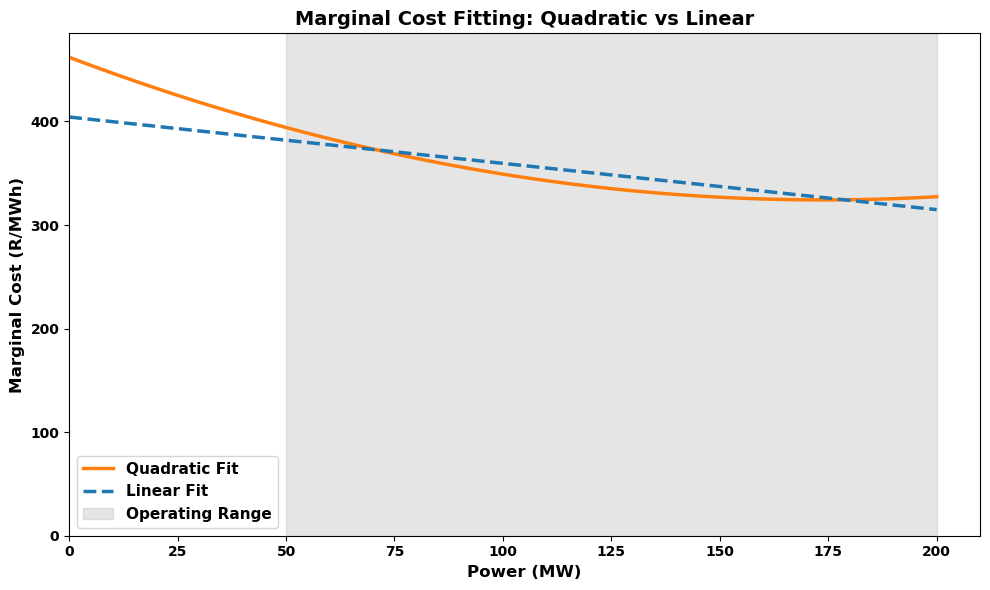

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot curves
ax.plot(p_nom_list, cost_quadratic, linewidth=2.5, label='Quadratic Fit', color='#ff7f0e')
ax.plot(p_nom_list, cost_linear, linewidth=2.5, label='Linear Fit', color='#1f77b4', linestyle='--')

# Shade region between x = 0.25 and x = 1
ax.axvspan(0.25*p_nom, p_nom, alpha=0.2, color='gray', label='Operating Range')

# Formatting
ax.set_xlabel('Power (MW)', fontsize=12)
ax.set_ylabel('Marginal Cost (R/MWh)', fontsize=12)
ax.set_title('Marginal Cost Fitting: Quadratic vs Linear', fontsize=14)
ax.legend(fontsize=11, loc='best')
ax.set_xlim(0, p_nom*1.05)
ax.set_ylim(0, max(max(cost_quadratic), max(cost_linear))*1.05)

plt.tight_layout()
plt.show()

In [ ]:



average_cost

np.float64(343.72897810955703)

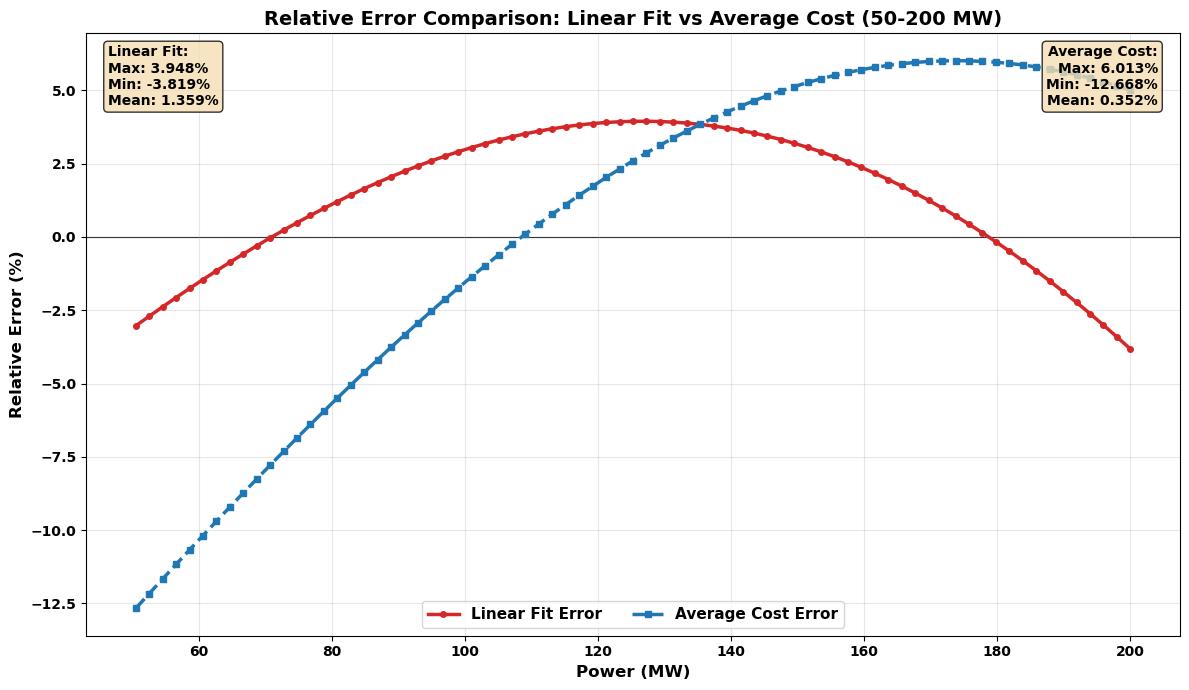

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Filter data for 50-200 MW range
mask = (p_nom_list >= 50) & (p_nom_list <= 200)
p_nom_filtered = p_nom_list[mask]
cost_quadratic_filtered = cost_quadratic[mask]
cost_linear_filtered = cost_linear[mask]

# Calculate relative errors
relative_error_linear = ((cost_linear_filtered - cost_quadratic_filtered) / cost_quadratic_filtered) * 100

# Calculate average quadratic cost
avg_quadratic_cost = cost_quadratic_filtered.mean()

# Calculate relative error using average cost
relative_error_avg = ((avg_quadratic_cost - cost_quadratic_filtered) / cost_quadratic_filtered) * 100

# Create plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot relative errors
ax.plot(p_nom_filtered, relative_error_linear, linewidth=2.5, color='#d62728', marker='o', markersize=4, label='Linear Fit Error')
# ax.fill_between(p_nom_filtered, relative_error_linear, alpha=0.2, color='#d62728')

ax.plot(p_nom_filtered, relative_error_avg, linewidth=2.5, color='#1f77b4', marker='s', markersize=4, label='Average Cost Error', linestyle='--')
# ax.fill_between(p_nom_filtered, relative_error_avg, alpha=0.2, color='#1f77b4')

# Add horizontal line at 0%
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-', zorder=1)

# Calculate statistics for linear fit
max_error_linear = relative_error_linear.max()
min_error_linear = relative_error_linear.min()
mean_error_linear = relative_error_linear.mean()

# Calculate statistics for average cost
max_error_avg = relative_error_avg.max()
min_error_avg = relative_error_avg.min()
mean_error_avg = relative_error_avg.mean()

# Add text boxes with statistics
textstr_linear = f'Linear Fit:\nMax: {max_error_linear:.3f}%\nMin: {min_error_linear:.3f}%\nMean: {mean_error_linear:.3f}%'
textstr_avg = f'Average Cost:\nMax: {max_error_avg:.3f}%\nMin: {min_error_avg:.3f}%\nMean: {mean_error_avg:.3f}%'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr_linear, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax.text(0.98, 0.98, textstr_avg, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=props)

# Formatting
ax.set_xlabel('Power (MW)', fontsize=12)
ax.set_ylabel('Relative Error (%)', fontsize=12)
ax.set_title('Relative Error Comparison: Linear Fit vs Average Cost (50-200 MW)', fontsize=14)
ax.legend(fontsize=11, loc='lower center', ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_supply_demand_curve(supplier_volume, supplier_prices, consumer_volume, consumer_prices, bus_name, snapshot_idx, n):
    """
    Plot supply and demand curves for a given bus and snapshot.
    
    Parameters:
    - supplier_volume: DataFrame of supplier volumes
    - supplier_prices: DataFrame of supplier prices
    - consumer_volume: DataFrame of consumer volumes
    - consumer_prices: DataFrame of consumer prices
    - bus_name: Name of the bus to plot
    - snapshot_idx: Index of the snapshot to plot
    - n: PyPSA network object
    """
    
    # Supply curve
    supply_at_bus = supplier_volume.iloc[snapshot_idx][supplier_volume.iloc[snapshot_idx] > 0]
    supply_prices_at_bus = supplier_prices.loc[n.snapshots[snapshot_idx], supply_at_bus.index]
    
    supply_curve = pd.DataFrame({
        'dispatch': supply_at_bus.values,
        'price': supply_prices_at_bus.values
    }, index=supply_at_bus.index)
    
    supply_curve = supply_curve[supply_curve['dispatch'] > 0].sort_values('price')
    
    # Demand curve
    demand_at_bus = consumer_volume.iloc[snapshot_idx][consumer_volume.iloc[snapshot_idx] > 0]
    demand_prices_at_bus = consumer_prices.loc[n.snapshots[snapshot_idx], demand_at_bus.index]
    
    demand_curve = pd.DataFrame({
        'dispatch': demand_at_bus.values,
        'price': demand_prices_at_bus.values
    }, index=demand_at_bus.index)
    
    demand_curve = demand_curve[demand_curve['dispatch'] > 0].sort_values('price', ascending=False)
    
    # Calculate max for xlim
    max_dispatch = max(supply_curve['dispatch'].sum(), demand_curve['dispatch'].sum())
    
    # Plot
    plt.figure(figsize=(10, 6))
    
    plt.step(
        np.cumsum([0] + supply_curve['dispatch'].tolist()),
        supply_curve['price'].iloc[:1].tolist() + supply_curve['price'].tolist(),
        where='pre',
        linewidth=2,
        color='steelblue',
        label='Supply'
    )
    
    if len(demand_curve) > 0:
        plt.step(
            np.cumsum([0] + demand_curve['dispatch'].tolist()),
            demand_curve['price'].iloc[:1].tolist() + demand_curve['price'].tolist(),
            where='pre',
            linewidth=2,
            color='coral',
            label='Demand'
        )
    
    plt.xlim(0, max_dispatch)
    plt.xlabel('Cumulative Dispatch (MW)')
    plt.ylabel('Price (ZAR/MWh)')
    plt.title(f'Supply-Demand Curve - {bus_name} at {n.snapshots[snapshot_idx]}(Snapshot {snapshot_idx})')
    plt.legend()
    plt.tight_layout()
    plt.show()




#### Case Description

Simulate least cost dispatch given fixed capacity availability with unit commitment and rolling horizon optimization.

##### PyPSA Features Used

| Feature | Method |
|---------|--------|
| Inspect dispatch data | Programmatically |
| Activate unit commitment for dispatchable generators | Programmatically |
| Apply quadratic marginal costs and standby costs | Programmatically |
| Run rolling horizon optimisation | Programmatically |
| Calculate marginal prices | Programmatically |
| Plot supply and demand | Programmatically |

##### Non-Standard PyPSA Features

These features are not standard in PyPSA but can be implemented through component manipulation:

| Feature | Method |
|---------|--------|
| Fitting heat rates to marginal costs | Inspect Excel file |
| Fitting offer curve to marginal costs | Inspect Excel file |

#### Lesson Tasks

1. Inspect market model results
2. Compare results with and without unit commitment
3. Compare how rolling horizon optimisation differs from full period optimisation

## Model

### User inputs

In [48]:
file_name = 'ich-single-node-v2.xlsx'
month = False # False : Insert month number (1-12) or False for full year simulation
week = False # False : Insert week number (1-52) or False for full year simulation

### Import packages, read input data and optimize

In [49]:
# Import packages
import pypsa                        # pypsa toolbox
import pandas as pd                 # pandas toolbox for handling tables
import plotly.graph_objects as go   # interactive plotting toolbox

# Supress unnecessary warnings
pd.set_option('future.no_silent_downcasting', True)

# The default plotting tool for pandas is matplotlib which only provies static plots. 
# Changing to plotly allows for interactive plotting. 
pd.set_option('plotting.backend', 'plotly')

# When pypsa version 1 was launched, a new set of commands were created. 
# This option ensures that we use the new commands. 
pypsa.options.api.new_components_api = True

In [50]:
# Model import and optimization
print(f'Load Network from {file_name}')
n = pypsa.Network(file_name)

# Import metadata (optional)
n.meta = pd.read_excel(file_name, sheet_name='meta', index_col=0, header=None)[1].to_dict()

# Reduce snapshots to month or week if specified (based on user inputs)
if month is not False: n.set_snapshots(n.snapshots[n.snapshots.month == month])
if week is not False: n.set_snapshots(n.snapshots[n.snapshots.isocalendar().week == week])

Load Network from ich-single-node-v2.xlsx


INFO:pypsa.network.io:Imported network 'ich-single-node-model' has buses, carriers, generators, global_constraints, lines, line_types, links, loads, processes, shapes, shunt_impedances, storage_units, stores, sub_networks, transformers, transformer_types


In [51]:
# set committable to True for dispatchable generators
dispatchable_carriers = ['coal', 'gas']
n.generators.static.loc[n.generators.static.carrier.isin(dispatchable_carriers), 'committable'] = True



In [ ]:
# Calculate marginal cost coefficients for coal generators using average cost

base_cost = 600
variable_operation_cost = 111 #EPRI report

for index,row in n.generators.static[n.generators.static.carrier == 'coal'].iterrows():
    power = row['p_nom']
    cost = base_cost * (400/power)**0.5
    print(f"Power: {power} MW, Marginal Cost: {cost:.2f} R/MWh")
    fitting_coeficients_quadratic = marginal_cost_coeff(power, calorific_value=18.5, coal_cost=cost, quadratic=True)
    cost_quadratic = quadratic_func(p_nom_list, *fitting_coeficients_quadratic)
    average_cost = cost_quadratic[(p_nom_list >= 50) & (p_nom_list <= 200)].mean()
    row['marginal_cost'] = average_cost + variable_operation_cost

Power: 400.0 MW, Marginal Cost: 600.00 R/MWh
Power: 300.0 MW, Marginal Cost: 692.82 R/MWh
Power: 250.0 MW, Marginal Cost: 758.95 R/MWh


In [ ]:
# Apply cost coefficients to calculate marginal cost, marginal cost with quadratic component, and standby cost for coal generators

base_cost = 600
variable_operation_cost = 111 #EPRI report

for index,row in n.generators.static[n.generators.static.carrier == 'coal'].iterrows():
    power = row['p_nom']
    cost = base_cost * (400/power)**0.5
    print(f"Power: {power} MW, Marginal Cost: {cost:.2f} R/MWh")
    fitting_coeficients_quadratic = marginal_cost_coeff(power, calorific_value=18.5, coal_cost=cost, quadratic=True)
    
    row['marginal_cost'] = fitting_coeficients_quadratic[0] + variable_operation_cost
    row['marginal_cost_quadratic'] = fitting_coeficients_quadratic[1] 
    row['standby_cost'] = fitting_coeficients_quadratic[2]


In [ ]:
# Set generators and storage units to be extendable if they are built in or after 2026.
n.generators.static.loc[n.generators.static.build_year >= 2026, 'p_nom_extendable'] = True

# Co-optimizing storage expansion is computationally expensive, so we will not do it in this case.
# n.storage_units.static.loc[n.storage_units.static.build_year >= 2026, 'p_nom_extendable'] = True 

# Downsample the network to speed up optimization (optional)
n.cluster.temporal.downsample(4)

# Limit wind expansion to 800 MW to avoid excessive expansion in this case.
n.generators.static.loc[(n.generators.static.build_year >= 2026) & (n.generators.static.carrier == 'wind'), 'p_nom_max'] = 800

# Add a global constraint to limit total CO2 emissions to 10,000 tons (example of adding a custom constraint)
n.add("GlobalConstraint", "CO2Limit", type="primary_energy", carrier_attribute="co2_emissions", sense="<=", constant=10000)


In [ ]:
# Run optimization

print('Run optimization')
# n.optimize.optimize_with_rolling_horizon(horizon=168,overlap=168-24,include_objective_constant = True)
n.optimize(include_objective_constant = True)

In [ ]:
n.statistics()

In [ ]:
carriers = ["solar", "wind", "gas"]
n.statistics.optimal_capacity.iplot.bar(build_year >=2016)

In [ ]:
capex = n.statistics.capex() # returns a series
capex.to_frame("capex")

In [ ]:
capex = n.statistics.capex() # returns a series
capex.to_frame("capex")

In [ ]:
system_cost = n.statistics.system_cost()
print(f"Total system cost: {system_cost.sum() / 1e9:.1f} bn ZAR")

In [ ]:
n.generators.dynamic.p.plot()

In [ ]:
costs = pd.concat([
    n.statistics.capex(groupby_method="sum").rename("sum"),
    n.statistics.capex(groupby_method="mean").rename("mean"),
], axis=1)
    
costs.sort_values(by="sum", ascending=False).div(1e6).style.format("{:,.0f} M€")

In [ ]:
caps = n.statistics.optimal_capacity()
caps.to_frame().head(10)

In [ ]:
cf = n.statistics.capacity_factor()
cf.sort_values(ascending=False).dropna()

In [ ]:
n.statistics.supply().sort_values(ascending=False).head(10)

In [ ]:
n.statistics.withdrawal().sort_values().head(10)

In [ ]:
eb = n.statistics.energy_balance()
eb.head(15)

In [ ]:
curt = n.statistics.curtailment()
curt[curt > 0].sort_values(ascending=False)

In [ ]:
prices = n.statistics.prices(groupby="bus_carrier")
print(f"Mean electricity price: {prices.mean():.2f} €/MWh")
prices.plot.barh(figsize=(6, 6), edgecolor="white", xlabel="€/MWh", ylabel="Bus Carrier")

In [ ]:
# optimal capacities - drop zero values and plot by carrier color
df_opt = n.generators.static.p_nom_opt[n.generators.static.p_nom_opt > 0]
df_opt.plot(kind='bar')

In [ ]:
n.statistics.revenue().sort_values(ascending=False).head(10)

In [ ]:
display(df_opt)

### Dispatch results

In [ ]:
n.generators.dynamic.p.plot()

In [ ]:
n.storage_units.dynamic.p.plot()

In [ ]:
pd.concat([n.generators.dynamic.p, n.storage_units.dynamic.p])

In [ ]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pandas as pd
from datetime import datetime

# 1. Split dispatch and storage
gen_dispatch = n.generators.dynamic.p
storage_discharge = n.generators.dynamic.p[n.storage_units.dynamic.p >= 0]  # Discharge (p >= 0)
storage_charge = n.storage_units.dynamic.p[n.storage_units.dynamic.p < 0].abs()  # Charge (p < 0, made positive)

# 2. Prepare data
charging = storage_charge.fillna(0)
generators = gen_dispatch.fillna(0)
discharging = storage_discharge.fillna(0)

# 3. Get load data
fixed_load = n.loads.dynamic.p.sum(axis=1)
elastic_load = n.generators.dynamic.p[n.generators.sign == -1].sum(axis=1)

# ============================================================================
# MATPLOTLIB VERSION
# ============================================================================

def plot_dispatch_matplotlib(start_date=None, end_date=None):
    """
    Plot dispatch with Matplotlib.
    
    Parameters:
    -----------
    start_date : str, optional
        Start date in format 'YYYY-MM-DD' (always 00:00)
    end_date : str, optional
        End date in format 'YYYY-MM-DD' (always 23:00)
    """
    
    # Filter data by date range
    if start_date and end_date:
        start_dt = pd.Timestamp(start_date + ' 00:00')
        end_dt = pd.Timestamp(end_date + ' 23:00')
        
        mask = (charging.index >= start_dt) & (charging.index <= end_dt)
        charging_filtered = charging[mask]
        generators_filtered = generators[mask]
        discharging_filtered = discharging[mask]
        fixed_load_filtered = fixed_load[mask]
        elastic_load_filtered = elastic_load[mask]
    else:
        charging_filtered = charging
        generators_filtered = generators
        discharging_filtered = discharging
        fixed_load_filtered = fixed_load
        elastic_load_filtered = elastic_load
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Stacked area plot
    ax.stackplot(
        charging_filtered.index,
        charging_filtered.sum(axis=1),
        generators_filtered.sum(axis=1),
        discharging_filtered.sum(axis=1),
        labels=['Charging Storage Units', 'Generator Dispatch', 'Discharging Storage Units'],
        alpha=0.7,
        colors=['#1f77b4', '#ff7f0e', '#2ca02c']
    )
    
    # Overlay loads
    ax.plot(fixed_load_filtered.index, fixed_load_filtered, color='black', linewidth=2.5, label='Total Fixed Load', zorder=5)
    ax.plot(elastic_load_filtered.index, elastic_load_filtered, color='red', linewidth=2.5, linestyle='--', label='Total Elastic Load', zorder=5)
    
    # Formatting
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Power (MW)', fontsize=12)
    ax.set_title('Dispatch with Storage Charging/Discharging and Load', fontsize=14)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Usage:
# plot_dispatch_matplotlib()  # All data
# plot_dispatch_matplotlib(start_date='2026-01-01', end_date='2026-01-05')

# ============================================================================
# PLOTLY VERSION
# ============================================================================

def plot_dispatch_plotly():
    """
    Plot dispatch with Plotly (interactive).
    """
    
    fig = go.Figure()
    
    # Add stacked area traces
    fig.add_trace(go.Scatter(
        x=charging.index,
        y=charging.sum(axis=1),
        mode='lines',
        name='Charging Storage Units',
        stackgroup='one',
        fillcolor='rgba(31, 119, 180, 0.7)',
        line=dict(color='rgba(31, 119, 180, 0.7)')
    ))
    
    fig.add_trace(go.Scatter(
        x=generators.index,
        y=generators.sum(axis=1),
        mode='lines',
        name='Generator Dispatch',
        stackgroup='one',
        fillcolor='rgba(255, 127, 14, 0.7)',
        line=dict(color='rgba(255, 127, 14, 0.7)')
    ))
    
    fig.add_trace(go.Scatter(
        x=discharging.index,
        y=discharging.sum(axis=1),
        mode='lines',
        name='Discharging Storage Units',
        stackgroup='one',
        fillcolor='rgba(44, 160, 44, 0.7)',
        line=dict(color='rgba(44, 160, 44, 0.7)')
    ))
    
    # Overlay loads
    fig.add_trace(go.Scatter(
        x=fixed_load.index,
        y=fixed_load,
        mode='lines',
        name='Total Fixed Load',
        line=dict(color='black', width=2.5),
        yaxis='y'
    ))
    
    fig.add_trace(go.Scatter(
        x=elastic_load.index,
        y=elastic_load,
        mode='lines',
        name='Total Elastic Load',
        line=dict(color='red', width=2.5, dash='dash'),
        yaxis='y'
    ))
    
    # Layout
    fig.update_layout(
        title='Dispatch with Storage Charging/Discharging and Load',
        xaxis_title='Time',
        yaxis_title='Power (MW)',
        hovermode='x unified',
        height=600,
        template='plotly_white'
    )
    
    fig.show()

# Usage:
# plot_dispatch_plotly()

### Post Process

In [ ]:
# Step 1: Separate volumes into suppliers and consumers
supplier_volume = pd.concat([
    n.generators.dynamic.p[n.generators.static[n.generators.static.type == 'Supply'].index],
    n.storage_units.dynamic.p[n.storage_units.dynamic.p >= 0].fillna(0)
], axis=1)

consumer_volume = pd.concat([
    n.loads.dynamic.p[n.loads.static[n.loads.static.type == 'Demand'].index],
    n.generators.dynamic.p[n.generators.static[n.generators.static.type == 'Demand'].index],
    n.storage_units.dynamic.p[n.storage_units.dynamic.p < 0].fillna(0)
], axis=1)

consumer_volume = consumer_volume.abs()

# Step 2: Get marginal costs for all generators and storage units
supplier_prices = pd.DataFrame(index=n.snapshots)
for gen in n.generators.static[n.generators.static.type == 'Supply'].index:
    if gen in n.generators.dynamic.marginal_cost.columns:
        supplier_prices[gen] = n.generators.dynamic.marginal_cost[gen]
    else:
        supplier_prices[gen] = n.generators.static.loc[gen, 'marginal_cost']

for storage in n.storage_units.static.index:
    if storage in n.storage_units.dynamic.marginal_cost.columns:
        supplier_prices[storage] = n.storage_units.dynamic.marginal_cost[storage]
    else:
        supplier_prices[storage] = n.storage_units.static.loc[storage, 'marginal_cost']

# Step 3: Find marginal cost (highest price among dispatched suppliers)
marginal_prices = supplier_prices[supplier_volume > 0].max(axis=1)

# Step 4: All consumers pay the marginal cost
consumer_prices = pd.DataFrame(index=n.snapshots)
for col in consumer_volume.columns:
    consumer_prices[col] = marginal_prices

# Step 5: Prepare offer and bid tables 
supplier_offers = pd.DataFrame(index=n.snapshots)

for gen in n.generators.static[n.generators.static['type'] == 'Supply'].index:
    if gen in n.generators.dynamic.p_max_pu.columns:
        supplier_offers[gen] = n.generators.dynamic.p_max_pu[gen] * n.generators.static.loc[gen, 'p_nom']
    else:
        supplier_offers[gen] = 1 * n.generators.static.loc[gen, 'p_nom']

for gen in n.generators.static[n.generators.static['type'] == 'Supply'].index:
    if gen in n.generators.dynamic.p_max_pu.columns:
        supplier_offers[gen] = n.generators.dynamic.p_max_pu[gen] * n.generators.static.loc[gen, 'p_nom']
    else:
        supplier_offers[gen] = 1 * n.generators.static.loc[gen, 'p_nom']


# Step 5: Calculate Curtailment using statistics library
curtailment = n.statistics.curtailment(carrier = ['solar','wind'],groupby_time = False).fillna(0)
curtailment = curtailment.xs('Generator', level=0).T # The curtailment results use the timestamp as columns, therefore we transpose the table (swop columns with rows).

### Results

#### Dispatch results

In [ ]:
n.generators.dynamic.status.plot()

In [ ]:
supplier_volume.plot.area(stacked=True)

In [ ]:

consumer_volume.plot.area(stacked=True)

In [ ]:
curtailment.plot(title = 'Renewables Curtailment')

#### Market Results

In [ ]:


fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(range(len(marginal_prices))),
    y=marginal_prices.values,
    mode='lines',
    hovertemplate='<b>Snapshot %{x}</b><br>Price: R%{y:.2f}/MWh<extra></extra>'
))

fig.update_layout(title='Marginal Prices with Timestamp')
fig.show()

In [ ]:
# Call the function
index = 30

plot_supply_demand_curve(supplier_offers, supplier_prices, consumer_volume, consumer_prices, 'Western Cape', index, n)

plot_supply_demand_curve(supplier_volume, supplier_prices, consumer_volume, consumer_prices, 'Western Cape', index, n)

In [ ]:
supplier_data = pd.DataFrame({
    'Offers (MWh)': supplier_offers.iloc[index, :],
    'Volume (MWh)': supplier_volume.iloc[index, :],
    'Prices (R/MWh)': supplier_prices.iloc[index, :],
})

consumer_data = pd.DataFrame({
    'Volume (MWh)': consumer_volume.iloc[index, :],
    'Prices (R/MWh)': consumer_prices.iloc[index, :],
})

# Create multi-index
supplier_data.index = pd.MultiIndex.from_product([['Supplier'], supplier_data.index])
consumer_data.index = pd.MultiIndex.from_product([['Consumer'], consumer_data.index])

# Combine
results = pd.concat([supplier_data, consumer_data], axis=0)
results = results.fillna(0)

print(f'Results for index - {index}: {n.snapshots[index]}')
display(results)

print()
print(f'Renewables curtailment (MWh) for index - {index}: {n.snapshots[index]}')
print(curtailment.iloc[index,:].to_string())

In [ ]:
# n.model.solver_model = None
# n.copy()

In [ ]:
import plotly.graph_objects as go
import pandas as pd

def xplot_supply_demand_curve(supplier_volume, supplier_prices, consumer_volume, consumer_prices, bus_name, n):
    """
    Plot supply and demand curves for a given bus with interactive snapshot selection via dropdown.
    """
    
    fig = go.Figure()
    
    # Generate curves for all snapshots
    for snapshot_idx in range(len(n.snapshots)):
        # Supply curve
        supply_at_bus = supplier_volume.iloc[snapshot_idx][supplier_volume.iloc[snapshot_idx] > 0]
        supply_prices_at_bus = supplier_prices.loc[n.snapshots[snapshot_idx], supply_at_bus.index]
        
        supply_curve = pd.DataFrame({
            'dispatch': supply_at_bus.values,
            'price': supply_prices_at_bus.values
        }, index=supply_at_bus.index)
        
        supply_curve = supply_curve[supply_curve['dispatch'] > 0].sort_values('price')
        
        # Demand curve
        demand_at_bus = consumer_volume.iloc[snapshot_idx][consumer_volume.iloc[snapshot_idx] > 0]
        demand_prices_at_bus = consumer_prices.loc[n.snapshots[snapshot_idx], demand_at_bus.index]
        
        demand_curve = pd.DataFrame({
            'dispatch': demand_at_bus.values,
            'price': demand_prices_at_bus.values
        }, index=demand_at_bus.index)
        
        demand_curve = demand_curve[demand_curve['dispatch'] > 0].sort_values('price', ascending=False)
        
        # Supply trace
        if len(supply_curve) > 0:
            supply_x = [0] + supply_curve['dispatch'].cumsum().tolist()
            supply_y = supply_curve['price'].iloc[:1].tolist() + supply_curve['price'].tolist()
            
            fig.add_trace(go.Scatter(
                x=supply_x, y=supply_y,
                mode='lines', name='Supply',
                line=dict(color='steelblue', width=2, shape='hv'),
                hovertemplate='<b>Supply</b><br>Cumulative: %{x:.0f} MW<br>Price: €%{y:.0f}/MWh<extra></extra>',
                visible=(snapshot_idx == 0)
            ))
        
        # Demand trace
        if len(demand_curve) > 0:
            demand_x = [0] + demand_curve['dispatch'].cumsum().tolist()
            demand_y = demand_curve['price'].iloc[:1].tolist() + demand_curve['price'].tolist()
            
            fig.add_trace(go.Scatter(
                x=demand_x, y=demand_y,
                mode='lines', name='Demand',
                line=dict(color='coral', width=2, shape='hv'),
                hovertemplate='<b>Demand</b><br>Cumulative: %{x:.0f} MW<br>Price: €%{y:.0f}/MWh<extra></extra>',
                visible=(snapshot_idx == 0)
            ))
    
    # Create dropdown buttons
    buttons = []
    for snapshot_idx in range(len(n.snapshots)):
        visible = [False] * len(fig.data)
        visible[snapshot_idx * 2] = True
        visible[snapshot_idx * 2 + 1] = True
        
        buttons.append(
            dict(
                label=f'{snapshot_idx}: {n.snapshots[snapshot_idx]}',
                method='update',
                args=[{'visible': visible},
                      {'title': f'Supply-Demand Curve - {bus_name} at {n.snapshots[snapshot_idx]} (Snapshot {snapshot_idx})'}]
            )
        )
    
    fig.update_layout(
        updatemenus=[dict(active=0, buttons=buttons, x=0.01, xanchor='left', y=1.15, yanchor='top')],
        title=f'Supply-Demand Curve - {bus_name} at {n.snapshots[0]} (Snapshot 0)',
        xaxis_title='Cumulative Dispatch (MW)',
        yaxis_title='Price (ZAR/MWh)',
        hovermode='x unified',
        height=600, width=900
    )
    
    fig.show()

In [ ]:
import plotly.graph_objects as go
import pandas as pd

def iplot_supply_demand_curve(supplier_volume, supplier_prices, consumer_volume, consumer_prices, bus_name, snapshot_idx, n):
    """
    Plot supply and demand curves for a given bus and snapshot using Plotly with step plot.
    
    Parameters:
    - supplier_volume: DataFrame of supplier volumes
    - supplier_prices: DataFrame of supplier prices
    - consumer_volume: DataFrame of consumer volumes
    - consumer_prices: DataFrame of consumer prices
    - bus_name: Name of the bus to plot
    - snapshot_idx: Index of the snapshot to plot
    - n: PyPSA network object
    """
    
    # Supply curve
    supply_at_bus = supplier_volume.iloc[snapshot_idx][supplier_volume.iloc[snapshot_idx] > 0]
    supply_prices_at_bus = supplier_prices.loc[n.snapshots[snapshot_idx], supply_at_bus.index]
    
    supply_curve = pd.DataFrame({
        'dispatch': supply_at_bus.values,
        'price': supply_prices_at_bus.values
    }, index=supply_at_bus.index)
    
    supply_curve = supply_curve[supply_curve['dispatch'] > 0].sort_values('price')
    
    # Demand curve
    demand_at_bus = consumer_volume.iloc[snapshot_idx][consumer_volume.iloc[snapshot_idx] > 0]
    demand_prices_at_bus = consumer_prices.loc[n.snapshots[snapshot_idx], demand_at_bus.index]
    
    demand_curve = pd.DataFrame({
        'dispatch': demand_at_bus.values,
        'price': demand_prices_at_bus.values
    }, index=demand_at_bus.index)
    
    demand_curve = demand_curve[demand_curve['dispatch'] > 0].sort_values('price', ascending=False)
    
    # Calculate max for xlim
    max_dispatch = max(supply_curve['dispatch'].sum(), demand_curve['dispatch'].sum())
    
    # Create figure
    fig = go.Figure()
    
    # Supply curve
    supply_x = [0] + supply_curve['dispatch'].cumsum().tolist()
    supply_y = supply_curve['price'].iloc[:1].tolist() + supply_curve['price'].tolist()
    
    fig.add_trace(go.Scatter(
        x=supply_x,
        y=supply_y,
        mode='lines',
        name='Supply',
        line=dict(color='steelblue', width=2, shape='hv'),
        hovertemplate='<b>Supply</b><br>Cumulative: %{x:.0f} MW<br>Price: €%{y:.0f}/MWh<extra></extra>'
    ))
    
    # Demand curve
    if len(demand_curve) > 0:
        demand_x = [0] + demand_curve['dispatch'].cumsum().tolist()
        demand_y = demand_curve['price'].iloc[:1].tolist() + demand_curve['price'].tolist()
        
        fig.add_trace(go.Scatter(
            x=demand_x,
            y=demand_y,
            mode='lines',
            name='Demand',
            line=dict(color='coral', width=2, shape='hv'),
            hovertemplate='<b>Demand</b><br>Cumulative: %{x:.0f} MW<br>Price: €%{y:.0f}/MWh<extra></extra>'
        ))
    
    # Update layout
    fig.update_layout(
        title=f'Supply-Demand Curve - {bus_name} at {n.snapshots[snapshot_idx]} (Snapshot {snapshot_idx})',
        xaxis_title='Cumulative Dispatch (MW)',
        yaxis_title='Price (ZAR/MWh)',
        hovermode='x unified',
        xaxis=dict(range=[0, max_dispatch]),
        height=600,
        width=900
    )
    
    fig.show()

In [ ]:
iplot_supply_demand_curve(supplier_offers, supplier_prices, consumer_volume, consumer_prices, 'Western Cape', index, n)

iplot_supply_demand_curve(supplier_volume, supplier_prices, consumer_volume, consumer_prices, 'Western Cape', index, n)